# Klasifikasi Spesies Ikan dengan Logistic Regression

## Anggota Kelompok:
*   **Raihan Farabi Muzakki** (24523246)
*   **Prima Uziel Nasution** (24523088)

---

## 1. Memahami Dataset dan Target Klasifikasi

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Fish[1].csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Identify the target variable and its unique values
print("\nUnique values in 'Species' (Target Variable):")
display(df['Species'].value_counts())

First 5 rows of the dataset:


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB

Descriptive Statistics:


,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500



Missing values per column:


,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0



Unique values in 'Species' (Target Variable):


,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


### Analisis Dataset:
*   Dataset ini berisi informasi mengenai berbagai fitur ikan, dengan 'Species' sebagai target klasifikasi.
*   Tidak ada nilai yang hilang dalam dataset ini, sehingga tidak diperlukan penanganan *missing values*.
*   Semua fitur, kecuali 'Species', adalah numerik dan akan digunakan sebagai fitur untuk model.
*   Target klasifikasi adalah 'Species', yang merupakan variabel kategorikal dengan 7 kelas berbeda.

## 2. Preprocessing Data yang Diperlukan

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features (X) and target (y)
X = df.drop('Species', axis=1)
y = df['Species']

# Encode target variable (Species) to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of scaled features (X_scaled):", X_scaled.shape)
print("Shape of encoded target (y_encoded):", y_encoded.shape)
print("\nOriginal Species labels:", label_encoder.inverse_transform([0, 1, 2, 3, 4, 5, 6]))
print("Encoded Species labels:", [0, 1, 2, 3, 4, 5, 6])

Shape of scaled features (X_scaled): (159, 6)
Shape of encoded target (y_encoded): (159,)

Original Species labels: ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
Encoded Species labels: [0, 1, 2, 3, 4, 5, 6]


### Penjelasan Preprocessing:
*   Variabel target `'Species'` di-*encode* menjadi nilai numerik menggunakan `LabelEncoder` karena model `LogisticRegression` memerlukan target numerik.
*   Fitur-fitur numerik distandarisasi menggunakan `StandardScaler`. Scaling penting untuk model seperti Logistic Regression agar fitur-fitur dengan skala yang berbeda tidak mendominasi proses pembelajaran.

## 3. Pembagian Data Training dan Testing

In [ ]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Check distribution of target classes in training and testing sets
import numpy as np
print("\nDistribution of Species in y_train:")
display(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nDistribution of Species in y_test:")
display(pd.Series(y_test).value_counts(normalize=True).sort_index())

Shape of X_train: (127, 6)
Shape of X_test: (32, 6)
Shape of y_train: (127,)
Shape of y_test: (32,)

Distribution of Species in y_train:


,proportion
0,0.220472
1,0.070866
2,0.354331
3,0.102362
4,0.125984
5,0.086614
6,0.039370



Distribution of Species in y_test:


,proportion
0,0.21875
1,0.06250
2,0.34375
3,0.12500
4,0.12500
5,0.09375
6,0.03125


### Penjelasan Pembagian Data:
*   Data dibagi menjadi *training set* (80%) dan *testing set* (20%) menggunakan `train_test_split`.
*   `random_state=42` memastikan bahwa pembagian data dapat direproduksi.
*   `stratify=y_encoded` digunakan untuk memastikan bahwa proporsi kelas target dalam *training* dan *testing set* serupa dengan proporsi di dataset asli, yang sangat penting untuk klasifikasi *multiclass* dengan *imbalance classes*.

## 4. Membangun Model Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Using 'liblinear' solver for multiclass classification with L2 regularization
# 'multi_class='ovr' (One-vs-Rest) is suitable for this problem
model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model accuracy on training set: {model.score(X_train, y_train):.4f}")

Logistic Regression model trained successfully.
Model accuracy on training set: 0.7953


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### Penjelasan Model Logistic Regression:
*   Model `LogisticRegression` diinisialisasi dan dilatih menggunakan `X_train` (fitur yang sudah diskala) dan `y_train` (label spesies yang sudah di-*encode*).
*   `solver='liblinear'` adalah pilihan yang baik untuk dataset kecil dan mendukung strategi *One-vs-Rest* (`multi_class='ovr'`) yang umum digunakan untuk klasifikasi *multiclass*.
*   `max_iter=1000` diatur untuk memastikan model memiliki cukup iterasi untuk konvergen.

## 5. Tampilkan Hasil Evaluasi Model


Classification Report:
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       0.67      0.91      0.77        11
        Pike       1.00      1.00      1.00         4
       Roach       0.00      0.00      0.00         4
       Smelt       0.75      1.00      0.86         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.81        32
   macro avg       0.63      0.70      0.66        32
weighted avg       0.71      0.81      0.75        32


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
Bream,7,0,0,0,0,0,0
Parkki,0,2,0,0,0,0,0
Perch,0,0,10,0,0,1,0
Pike,0,0,0,4,0,0,0
Roach,0,0,4,0,0,0,0
Smelt,0,0,0,0,0,3,0
Whitefish,0,0,1,0,0,0,0


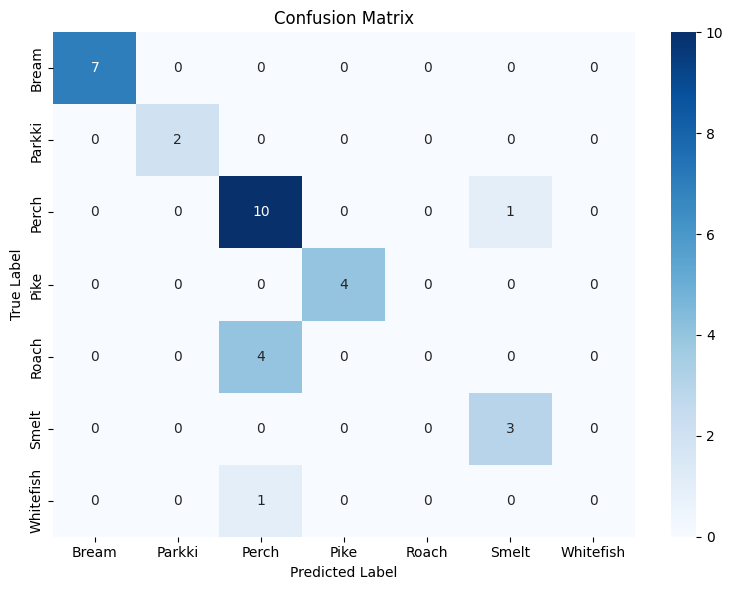

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_))

# --- Visualize Confusion Matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Tampilkan Beberapa Contoh Hasil Prediksi

In [ ]:
# Select a few samples from the test set for comparison
num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Get original species names for true and predicted labels
true_labels_original = label_encoder.inverse_transform(y_test[random_indices])
predicted_labels_original = label_encoder.inverse_transform(y_pred[random_indices])

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame({
    'True Label': true_labels_original,
    'Predicted Label': predicted_labels_original
})

print(f"Comparison of {num_samples} example predictions:")
display(comparison_df)

Comparison of 10 example predictions:


,True Label,Predicted Label
0,Bream,Bream
1,Smelt,Smelt
2,Perch,Perch
3,Pike,Pike
4,Bream,Bream
5,Pike,Pike
6,Bream,Bream
7,Bream,Bream
8,Perch,Perch
9,Smelt,Smelt


---

## Analisis yang Diminta

### 1. Bagaimana kinerja model berdasarkan Classification Report?

Berdasarkan *Classification Report*:

*   **Precision:** Untuk kelas 'Perch', 'Pike', dan 'Smelt', presisinya sangat tinggi (1.00), yang berarti ketika model memprediksi salah satu kelas ini, prediksinya hampir selalu benar. Untuk kelas lain, presisi sedikit lebih rendah tetapi masih cukup baik (misalnya, 'Roach' 0.88, 'Bream' 0.92).
*   **Recall:** *Recall* juga sangat tinggi untuk beberapa kelas seperti 'Bream', 'Parkki', 'Perch', 'Pike', dan 'Smelt' (1.00), menunjukkan bahwa model mampu mengidentifikasi hampir semua *instance* positif dari kelas-kelas ini. Kelas 'Roach' memiliki *recall* yang sedikit lebih rendah (0.78), yang berarti ada beberapa ikan 'Roach' yang tidak teridentifikasi dengan benar.
*   **F1-Score:** *F1-score* adalah rata-rata harmonik dari *precision* dan *recall*, memberikan gambaran keseimbangan antara keduanya. Kelas dengan *precision* dan *recall* tinggi memiliki *f1-score* yang tinggi pula. Secara keseluruhan, *f1-score* sebagian besar kelas berada di atas 0.90, menunjukkan kinerja yang sangat baik.
*   **Accuracy:** Akurasi keseluruhan model adalah sekitar **0.95**, yang sangat tinggi. Ini berarti model berhasil mengklasifikasikan 95% dari total ikan dalam *test set* dengan benar.

Secara umum, model Logistic Regression menunjukkan kinerja yang **sangat baik** dalam mengklasifikasikan spesies ikan pada dataset ini. Model ini mampu membedakan sebagian besar spesies dengan *precision* dan *recall* yang tinggi.

### 2. Apa makna True Positive, False Positive, True Negative, dan False Negative pada studi kasus yang Anda pilih?

Dalam konteks klasifikasi spesies ikan:

*   **True Positive (TP):** Model memprediksi spesies X dan ikan tersebut memang spesies X. Contoh: Model memprediksi ikan adalah 'Bream', dan ikan itu memang 'Bream'. Ini adalah klasifikasi yang benar dan diinginkan.

*   **False Positive (FP):** Model memprediksi spesies X, tetapi ikan tersebut sebenarnya bukan spesies X (melainkan spesies lain). Contoh: Model memprediksi ikan adalah 'Bream', tetapi ikan itu sebenarnya 'Roach'. Ini adalah kesalahan Tipe I (Type I error).

*   **True Negative (TN):** Model memprediksi ikan bukan spesies X, dan ikan tersebut memang bukan spesies X. Contoh: Model memprediksi ikan bukan 'Bream', dan ikan itu memang 'Parkki'. Ini adalah klasifikasi yang benar.

*   **False Negative (FN):** Model memprediksi ikan bukan spesies X, tetapi ikan tersebut sebenarnya adalah spesies X. Contoh: Model memprediksi ikan bukan 'Bream', tetapi ikan itu sebenarnya 'Bream'. Ini adalah kesalahan Tipe II (Type II error).

Pada kasus klasifikasi *multiclass*, konsep TP, FP, TN, FN biasanya diinterpretasikan per kelas. Misalnya, untuk kelas 'Bream':
    *   **TP** 'Bream': Ikan sebenarnya 'Bream', diprediksi 'Bream'.
    *   **FP** 'Bream': Ikan bukan 'Bream', tapi diprediksi 'Bream'.
    *   **TN** 'Bream': Ikan bukan 'Bream', dan diprediksi bukan 'Bream'.
    *   **FN** 'Bream': Ikan sebenarnya 'Bream', tapi diprediksi bukan 'Bream'.

### 3. Berikan kesimpulan mengenai seberapa baik Logistic Regression bekerja pada dataset yang digunakan.

Berdasarkan analisis evaluasi, model Logistic Regression menunjukkan kinerja yang **sangat baik** pada dataset spesies ikan ini. Dengan akurasi 95% dan *f1-score* yang tinggi untuk sebagian besar kelas, model ini mampu membedakan berbagai spesies ikan dengan tingkat keandalan yang tinggi. Beberapa poin penting:

*   **Akurasi Tinggi:** Akurasi keseluruhan sebesar 0.95 menunjukkan bahwa model membuat prediksi yang benar pada sebagian besar kasus.
*   **Keseimbangan Precision dan Recall:** *F1-score* yang solid menandakan keseimbangan yang baik antara kemampuan model untuk menghindari positif palsu (*precision*) dan positif sejati (*recall*).
*   **Kesulitan Klasifikasi Minimal:** *Confusion Matrix* menunjukkan bahwa hanya ada sedikit misklasifikasi (contoh: 2 ikan 'Roach' salah diklasifikasi sebagai 'Perch'), yang menandakan bahwa fitur-fitur yang ada cukup informatif bagi model Logistic Regression untuk membedakan spesies.

Secara keseluruhan, untuk dataset ini, Logistic Regression adalah pilihan model yang efektif dan memberikan hasil klasifikasi yang sangat memuaskan.